In [6]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
from dotenv import load_dotenv
import os

load_dotenv()

HOST = os.getenv("HOST")
DATABASE = os.getenv("DATABASE")
USER = os.getenv("USER")
PASSWORD = os.getenv("PASSWORD")
PORT = os.getenv("PORT")

# Bỏ qua cảnh báo của pandas khi dùng psycopg2 trực tiếp với read_sql
warnings.filterwarnings('ignore', category=UserWarning)

try:
    # 1. Kết nối và lấy dữ liệu
    conn = psycopg2.connect(
        host=HOST,
        database=DATABASE,
        user=USER,
        password=PASSWORD,
        port=PORT  # mặc định là 5432
    )
    
    print("Kết nối database thành công!")

    query = """SELECT * FROM "stroke_data";"""
    df = pd.read_sql(query, con=conn)
    print(f"Đã lấy dữ liệu thành công! Kích thước dữ liệu: {df.shape}")

except Exception as e:
    print("Lỗi khi kết nối hoặc lấy dữ liệu:", e)
    df = None # Gán None nếu lỗi để tránh lỗi ở phần sau

finally:
    # Đảm bảo đóng kết nối sau khi lấy xong data
    if 'conn' in locals() and conn:
        conn.close()
        print("Đã đóng kết nối database an toàn.\n")

Lỗi khi kết nối hoặc lấy dữ liệu: connection to server at "localhost" (::1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?



stroke               0    1
smoking_status             
formerly smoked   6822  180
never smoked     21628  257
smokes            6105  112
______
stroke                      0           1
smoking_status                           
formerly smoked   6892.494018  109.505982
never smoked     21542.735158  342.264842
smokes            6119.770824   97.229176
______
stroke                  0         1
smoking_status                     
formerly smoked -0.849110  6.736485
never smoked     0.580924 -4.608810
smokes          -0.188815  1.497981
______


<Figure size 800x600 with 0 Axes>

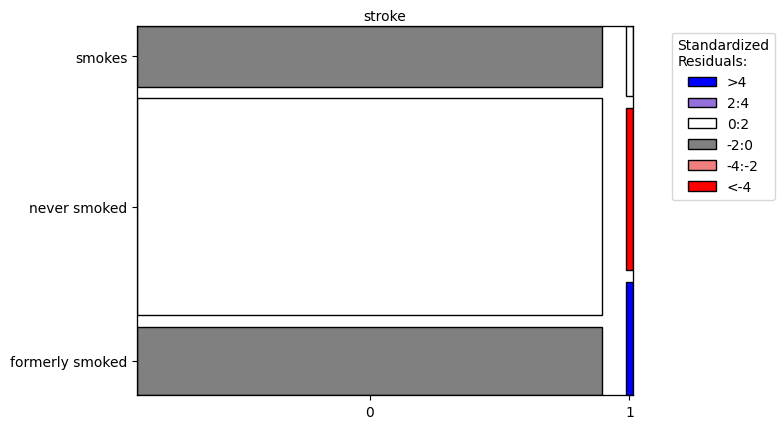

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic
from scipy.stats import chi2_contingency
from matplotlib.patches import Patch

# 1. Tạo bảng tần số
table = pd.crosstab(df['smoking_status'], df['stroke'])
print(table)
print('______')

# 2. Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

expected_table = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print(expected_table)
print('______')
# 3. Tính standardized residuals
residuals = (table - expected) / np.sqrt(expected)
print(residuals)
print('______')
# 4. Hàm chọn màu theo residual
def colorizer(key):
    smoking, stroke = key
    stroke = int(stroke)
    r = residuals.loc[smoking, stroke]

    if r < -4:
        return 'red'
    elif r < -2:
        return 'lightcoral'
    elif r < 0:
        return 'gray'
    elif r < 2:
        return 'white'
    elif r < 4:
        return 'mediumpurple'
    else:
        return 'blue'

# 5. Đảo trục để stroke nằm ngang
mosaic_data = table.T.stack().to_dict()

plt.figure(figsize=(8,6))

# 6. Vẽ mosaic plot
mosaic(
    mosaic_data,
    gap=0.05,
    labelizer=lambda key: "",  
    properties=lambda key: {
        'facecolor': 'white' if key[0] == 0 else colorizer((key[1], key[0])),
        'edgecolor': 'black',
        'linestyle': '-'
    }
)

plt.xlabel("stroke")
plt.ylabel("smoking status")

# 7. Tạo legend
legend_elements = [
    Patch(facecolor='blue', edgecolor='black', label='>4'),
    Patch(facecolor='mediumpurple', edgecolor='black', label='2:4'),
    Patch(facecolor='white', edgecolor='black', label='0:2'),
    Patch(facecolor='gray', edgecolor='black', label='-2:0'),
    Patch(facecolor='lightcoral', edgecolor='black', label='-4:-2'),
    Patch(facecolor='red', edgecolor='black', label='<-4')
]

plt.legend(
    handles=legend_elements,
    title="Standardized\nResiduals:",
    bbox_to_anchor=(1.3,1)
)

plt.show()